### Version 2 - Rebuilding on new clean data
What changed -
- sentinel values properly handled in EDA
- leaking columns removed
- interaction feature added (speed_x_area)

I will use same binary approach Fatal vs Non Fatal

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("../data/processed/accidents_features.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (106004, 20)
Columns: ['collision_severity', 'road_type', 'speed_limit', 'urban_or_rural_area', 'junction_detail', 'junction_control', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'carriageway_hazards', 'number_of_vehicles', 'number_of_casualties', 'vehicle_type_mode', 'any_skidding', 'avg_vehicle_age', 'time_sin', 'time_cos', 'day_sin', 'day_cos', 'speed_x_area']


In [4]:
print("Class distribution:")
print(df["collision_severity"].value_counts().sort_index())

Class distribution:
collision_severity
1     1602
2    23333
3    81069
Name: count, dtype: int64


In [5]:
X = df.drop(columns=["collision_severity"])
y = (df["collision_severity"] == 1).astype(int)

In [6]:
print(X.shape)
print("Fatal(1):", y.sum(), "-Non fatal(0):", (y==0).sum())

(106004, 19)
Fatal(1): 1602 -Non fatal(0): 104402


In [9]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, 
                                                     random_state=42, stratify=y)

In [10]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (84803, 19)
Test: (21201, 19)


In [11]:
# scale_pos_weight for class imbalance
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_weight:.1f}")

scale_pos_weight: 65.1


In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []

In [17]:
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    model = XGBClassifier(n_estimators=200, scale_pos_weight=scale_weight, max_depth=6,
    learning_rate=0.1, random_state=42, verbosity=0)

    model.fit(X_fold_train, y_fold_train)

    y_proba = model.predict_proba(X_fold_val)[:, 1]
    auc = roc_auc_score(y_fold_val, y_proba)
    auc_scores.append(auc)

    print(f"Fold {fold+1}: AUC = {auc:.3f}")
print(f"\nMean AUC: {np.mean(auc_scores):.3f}")
print(f"Std  AUC: {np.std(auc_scores):.3f}")

Fold 1: AUC = 0.737
Fold 2: AUC = 0.775
Fold 3: AUC = 0.770
Fold 4: AUC = 0.757
Fold 5: AUC = 0.750

Mean AUC: 0.758
Std  AUC: 0.014


In [18]:
df_v1 = pd.read_csv("../data/processed/accidents_clean.csv")
print(df_v1.columns.tolist())

['collision_severity', 'day_of_week', 'time', 'road_type', 'speed_limit', 'urban_or_rural_area', 'junction_detail', 'junction_control', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'carriageway_hazards', 'number_of_vehicles', 'number_of_casualties', 'vehicle_type_mode', 'any_skidding', 'avg_vehicle_age', 'worst_casualty_severity', 'any_pedestrian', 'avg_casualty_age']


In [19]:
print("junction_control -1 count:", (X_train["junction_control"] == -1).sum())
print("junction_detail -1 count:", (X_train["junction_detail"] == -1).sum())

junction_control -1 count: 36022
junction_detail -1 count: 1434


In [23]:
categorical_cols = [
    "road_type", "urban_or_rural_area", "junction_detail",
    "junction_control", "light_conditions", "weather_conditions",
    "road_surface_conditions", "vehicle_type_mode"
]

# convert to category dtype 

X_train_v2 = X_train.copy()
X_test_v2 = X_test.copy()

for col in categorical_cols:
    X_train_v2[col] = X_train_v2[col].astype("category")
    X_test_v2[col] = X_test_v2[col].astype("category")

print(categorical_cols)

['road_type', 'urban_or_rural_area', 'junction_detail', 'junction_control', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'vehicle_type_mode']


In [24]:
auc_scores_v2 = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_v2, y_train)):

    X_fold_train = X_train_v2.iloc[train_idx]
    X_fold_val = X_train_v2.iloc[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    model = XGBClassifier(
        n_estimators=200,
        scale_pos_weight=scale_weight,
        max_depth=6,
        learning_rate=0.1,
        enable_categorical=True,
        random_state=42,
        verbosity=0
    )

    model.fit(X_fold_train, y_fold_train)

    y_proba = model.predict_proba(X_fold_val)[:, 1]
    auc = roc_auc_score(y_fold_val, y_proba)
    auc_scores_v2.append(auc)

    print(f"Fold {fold+1}: AUC = {auc:.3f}")

print(f"\nMean AUC: {np.mean(auc_scores_v2):.3f}")
print(f"Std AUC: {np.std(auc_scores_v2):.3f}")

Fold 1: AUC = 0.749
Fold 2: AUC = 0.784
Fold 3: AUC = 0.768
Fold 4: AUC = 0.760
Fold 5: AUC = 0.748

Mean AUC: 0.762
Std AUC: 0.013


In [25]:
auc_scores_v3 = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_v2, y_train)):

    X_fold_train = X_train_v2.iloc[train_idx]
    X_fold_val = X_train_v2.iloc[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    model = XGBClassifier(
        n_estimators=300,
        scale_pos_weight=scale_weight,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        enable_categorical=True,
        random_state=42,
        verbosity=0
    )

    model.fit(X_fold_train, y_fold_train)

    y_proba = model.predict_proba(X_fold_val)[:, 1]
    auc = roc_auc_score(y_fold_val, y_proba)
    auc_scores_v3.append(auc)

    print(f"Fold {fold+1}: AUC = {auc:.3f}")

print(f"\nMean AUC: {np.mean(auc_scores_v3):.3f}")
print(f"Std AUC: {np.std(auc_scores_v3):.3f}")

Fold 1: AUC = 0.791
Fold 2: AUC = 0.810
Fold 3: AUC = 0.812
Fold 4: AUC = 0.814
Fold 5: AUC = 0.785

Mean AUC: 0.802
Std AUC: 0.012


### Note:
Here Mean AUC is improved from 0.758 (first version) to 0.802.

In [28]:
import joblib
import os

final_model = XGBClassifier(
    n_estimators=300,
    scale_pos_weight=scale_weight,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    enable_categorical=True,
    random_state=42,
    verbosity=0
)

final_model.fit(X_train_v2, y_train)

y_pred = final_model.predict(X_test_v2)
y_proba = final_model.predict_proba(X_test_v2)[:, 1]

print("FINAL MODEL Test Set")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")
print(classification_report(y_test, y_pred, target_names=["Non-Fatal", "Fatal"]))

os.makedirs("../models", exist_ok=True)
joblib.dump(final_model, "../models/xgb_fatal_predictorv2.pkl")
print("Model saved.")

FINAL MODEL Test Set
AUC-ROC: 0.825
              precision    recall  f1-score   support

   Non-Fatal       0.99      0.78      0.87     20881
       Fatal       0.05      0.71      0.09       320

    accuracy                           0.78     21201
   macro avg       0.52      0.74      0.48     21201
weighted avg       0.98      0.78      0.86     21201

Model saved.


## Model results
Improvement over first version:
- AUC-ROC: 0.800 -> 0.825
- Fatal recall: 0.53 -> 0.71

Improvement over naive baseline:
- AUC-ROC: 0.500 -> 0.825
- Fatal recall: 0 -. 71%

In [29]:
import shap

In [30]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_v2)

In [31]:
shap_values.shape

(21201, 19)

In [32]:
X_test_v2.shape

(21201, 19)

In [33]:
import matplotlib.pyplot as plt

In [34]:
mean_shap = np.abs(shap_values).mean(axis=0)
feature_names = X_test_v2.columns.tolist()

In [35]:
for i, name in enumerate(feature_names):
    print(f"{name}:{mean_shap[i]:.4f}")

road_type:0.1903
speed_limit:0.2721
urban_or_rural_area:0.0344
junction_detail:0.0646
junction_control:0.1405
light_conditions:0.1239
weather_conditions:0.1031
road_surface_conditions:0.0467
carriageway_hazards:0.0461
number_of_vehicles:0.4297
number_of_casualties:0.2001
vehicle_type_mode:0.2943
any_skidding:0.2598
avg_vehicle_age:0.0784
time_sin:0.1825
time_cos:0.2104
day_sin:0.0343
day_cos:0.0913
speed_x_area:0.4123


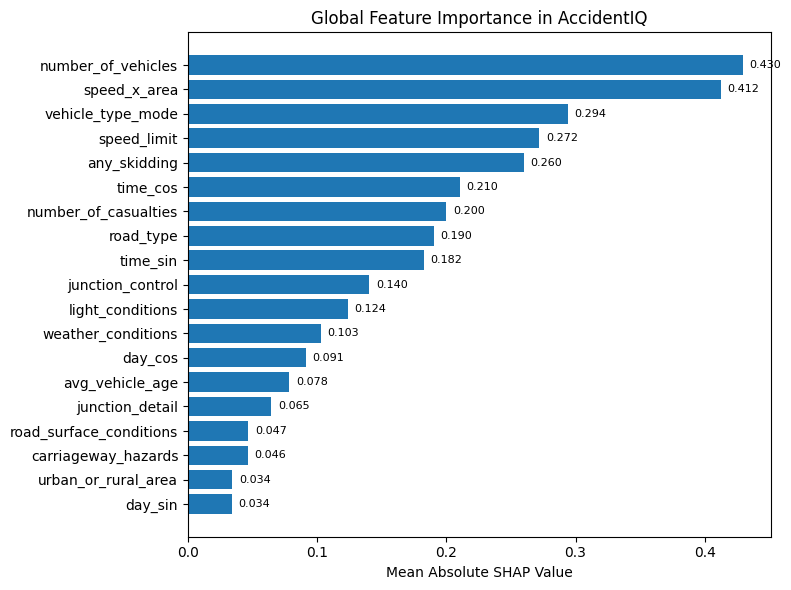

In [38]:
indices = np.argsort(mean_shap)
sorted_names = [feature_names[i] for i in indices]
sorted_values = [mean_shap[i] for i in indices]

plt.figure(figsize=(8, 6))
plt.barh(sorted_names, sorted_values, color="#1f77b4")

for i, val in enumerate(sorted_values):
    plt.text(val + 0.005, i, f"{val:.3f}", va="center", fontsize=8)

plt.xlabel("Mean Absolute SHAP Value")
plt.title("Global Feature Importance in AccidentIQ")
plt.tight_layout()
plt.savefig("../reports/figures/shap_global.png", dpi=100, bbox_inches="tight")
plt.show()

In [41]:
# finding first fatal accident in test set
fatal_indices = X_test_v2[y_test == 1].index.tolist()
print(f"Fatal accidents in test set:{len(fatal_indices)}")

Fatal accidents in test set:320


In [42]:
# take the first one
example_idx = fatal_indices[0]
example = X_test_v2.loc[[example_idx]]

In [43]:
# model prediction
all_probs = final_model.predict_proba(example)
fatal_prob = all_probs[0][1]

print(f"\nModel Fatal probability: {fatal_prob:.3f}")


Model Fatal probability: 0.740


In [44]:
if y_test.loc[example_idx] == 1:
    print("Actual label: Fatal")
else:
    print("Actual label: Non-Fatal")

print("\nAccident conditions:")
for col in example.columns:
    print(f"{col}:{example[col].values[0]}")

Actual label: Fatal

Accident conditions:
road_type:7
speed_limit:70
urban_or_rural_area:2
junction_detail:0
junction_control:-1
light_conditions:4
weather_conditions:1
road_surface_conditions:2
carriageway_hazards:0
number_of_vehicles:1
number_of_casualties:1
vehicle_type_mode:21
any_skidding:0
avg_vehicle_age:4.0
time_sin:0.3502073812594674
time_cos:0.9366721892483976
day_sin:-0.7818314824680299
day_cos:0.6234898018587334
speed_x_area:140


In [46]:
example_shap = explainer.shap_values(example)

local_shap = []
for i, name in enumerate(feature_names):
    local_shap.append((name, example_shap[0][i]))

local_shap.sort(key=lambda x: x[1], reverse=True)

print("Features pushing TOWARD Fatal +ve:")
for name, val in local_shap:
    if val > 0:
        print(f"{name}:+{val:.3f}")

print("\nFeatures pushing AWAY from Fatal -ve:")
for name, val in local_shap:
    if val < 0:
        print(f"{name}:{val:.3f}")

Features pushing TOWARD Fatal +ve:
vehicle_type_mode:+0.853
number_of_vehicles:+0.414
time_sin:+0.252
time_cos:+0.215
speed_x_area:+0.195
junction_control:+0.108
speed_limit:+0.103
any_skidding:+0.063
light_conditions:+0.060
day_cos:+0.050
weather_conditions:+0.038
urban_or_rural_area:+0.028
carriageway_hazards:+0.018

Features pushing AWAY from Fatal -ve:
avg_vehicle_age:-0.005
day_sin:-0.012
road_surface_conditions:-0.014
junction_detail:-0.016
number_of_casualties:-0.131
road_type:-1.285
